# 01 - Exploratory Analysis: COMPAS Recidivism Dataset

**Dataset:** COMPAS Recidivism Risk Score Data (ProPublica)  
**Objetivo:** Analisar a estrutura, qualidade e distribuições do dataset para informar decisões de sanitização e anonimização.

**Objetivo de divulgação:** Permitir a análise de possíveis disparidades raciais nos scores de risco de reincidência (COMPAS), por género e faixa etária, sem identificar os indivíduos avaliados.

In [19]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os

sns.set_theme(style="whitegrid")

df = pd.read_csv('../data/original/compas-scores-raw.csv')
print(f"Linhas: {len(df)}, Colunas: {len(df.columns)}")
print(f"Pessoas únicas (Person_ID): {df['Person_ID'].nunique()}")

Linhas: 60843, Colunas: 28
Pessoas únicas (Person_ID): 18610


## 1. Estrutura do Dataset

Cada pessoa tem **3 linhas** (uma por tipo de score: Risk of Violence, Risk of Recidivism, Risk of Failure to Appear).

In [20]:
# Tipos de dados e colunas
print("=== Colunas e Tipos ===")
print(df.dtypes)
print(f"\n=== Registos por pessoa ===")
vc = df['Person_ID'].value_counts()
print(f"  3 registos: {(vc==3).sum()} pessoas")
print(f"  6 registos: {(vc==6).sum()} pessoas")
print(f"  Outros: {(~vc.isin([3,6])).sum()} pessoas")

=== Colunas e Tipos ===
Person_ID                    int64
AssessmentID                 int64
Case_ID                      int64
Agency_Text                    str
LastName                       str
FirstName                      str
MiddleName                     str
Sex_Code_Text                  str
Ethnic_Code_Text               str
DateOfBirth                    str
ScaleSet_ID                  int64
ScaleSet                       str
AssessmentReason               str
Language                       str
LegalStatus                    str
CustodyStatus                  str
MaritalStatus                  str
Screening_Date                 str
RecSupervisionLevel          int64
RecSupervisionLevelText        str
Scale_ID                     int64
DisplayText                    str
RawScore                   float64
DecileScore                  int64
ScoreText                      str
AssessmentType                 str
IsCompleted                  int64
IsDeleted                    in

## 2. Qualidade dos Dados - Valores Nulos e Constantes

In [21]:
# Valores nulos
print("=== Valores Nulos ===")
nulls = df.isnull().sum()
nulls_pct = (nulls / len(df) * 100).round(2)
print(pd.DataFrame({'nulls': nulls, '%': nulls_pct}))

print("\n=== Colunas com 1 só valor (inúteis) ===")
for col in df.columns:
    if df[col].nunique() <= 1:
        print(f"  {col}: {df[col].unique()}")

print("\n=== Valores únicos por coluna ===")
for col in df.columns:
    print(f"  {col}: {df[col].nunique()} únicos")

=== Valores Nulos ===
                         nulls      %
Person_ID                    0   0.00
AssessmentID                 0   0.00
Case_ID                      0   0.00
Agency_Text                  0   0.00
LastName                     0   0.00
FirstName                    0   0.00
MiddleName               45219  74.32
Sex_Code_Text                0   0.00
Ethnic_Code_Text             0   0.00
DateOfBirth                  0   0.00
ScaleSet_ID                  0   0.00
ScaleSet                     0   0.00
AssessmentReason             0   0.00
Language                     0   0.00
LegalStatus                  0   0.00
CustodyStatus                0   0.00
MaritalStatus                0   0.00
Screening_Date               0   0.00
RecSupervisionLevel          0   0.00
RecSupervisionLevelText      0   0.00
Scale_ID                     0   0.00
DisplayText                  0   0.00
RawScore                     0   0.00
DecileScore                  0   0.00
ScoreText                   

## 3. Distribuição dos Atributos Categóricos

Analisar os valores de cada atributo categórico que vamos manter.

In [22]:
cat_cols = ['Sex_Code_Text', 'Ethnic_Code_Text', 'MaritalStatus', 'Language',
            'LegalStatus', 'CustodyStatus', 'Agency_Text', 'RecSupervisionLevelText']

for col in cat_cols:
    print(f"\n=== {col} ({df[col].nunique()} valores) ===")
    vc = df[col].value_counts()
    vc_pct = (vc / len(df) * 100).round(2)
    print(pd.DataFrame({'count': vc, '%': vc_pct}).to_string())


=== Sex_Code_Text (2 valores) ===
               count      %
Sex_Code_Text              
Male           47514  78.09
Female         13329  21.91

=== Ethnic_Code_Text (9 valores) ===
                  count      %
Ethnic_Code_Text              
African-American  27018  44.41
Caucasian         21783  35.80
Hispanic           8742  14.37
Other              2592   4.26
Asian               324   0.53
Native American     219   0.36
Arabic               75   0.12
African-Am           51   0.08
Oriental             39   0.06

=== MaritalStatus (7 valores) ===
                   count      %
MaritalStatus                  
Single             45126  74.17
Married             8172  13.43
Divorced            3879   6.38
Separated           1803   2.96
Significant Other   1260   2.07
Widowed              390   0.64
Unknown              213   0.35

=== Language (2 valores) ===
          count      %
Language              
English   60591  99.59
Spanish     252   0.41

=== LegalStatus (7 valores) 

## 4. Distribuição dos Scores (Sensitive Attributes)

`RawScore` e `DecileScore` são os atributos sensitive. Precisam de ter muitos valores distintos para l-Diversity.

In [23]:
# Estatísticas dos scores por tipo
for score_type in ['Risk of Recidivism', 'Risk of Violence', 'Risk of Failure to Appear']:
    subset = df[df['DisplayText'] == score_type]
    print(f"\n=== {score_type} ===")
    print(f"  RawScore: {subset['RawScore'].nunique()} valores únicos")
    print(subset['RawScore'].describe(percentiles=[.01, .05, .25, .5, .75, .95, .99]).round(2))
    print(f"\n  DecileScore:")
    print(subset['DecileScore'].value_counts().sort_index())


=== Risk of Recidivism ===
  RawScore: 457 valores únicos
count    20281.00
mean        -0.77
std          0.85
min         -3.21
1%          -2.59
5%          -2.20
25%         -1.38
50%         -0.76
75%         -0.15
95%          0.59
99%          0.98
max          2.36
Name: RawScore, dtype: float64

  DecileScore:
DecileScore
-1       36
 1     4560
 2     2779
 3     2249
 4     2031
 5     1767
 6     1700
 7     1520
 8     1351
 9     1304
 10     984
Name: count, dtype: int64

=== Risk of Violence ===
  RawScore: 485 valores únicos
count    20281.00
mean        -2.52
std          0.89
min         -4.79
1%          -4.28
5%          -3.96
25%         -3.18
50%         -2.53
75%         -1.90
95%         -1.01
99%         -0.50
max          1.52
Name: RawScore, dtype: float64

  DecileScore:
DecileScore
-1        9
 1     6781
 2     3194
 3     2660
 4     2011
 5     1573
 6     1406
 7      965
 8      721
 9      642
 10     319
Name: count, dtype: int64

=== Risk of Failu

## 5. Análise de Idade (derivada de DateOfBirth)

Converter `DateOfBirth` para idade e analisar a distribuição.

In [24]:
# Calcular idade a partir de DateOfBirth e Screening_Date
df['DateOfBirth'] = pd.to_datetime(df['DateOfBirth'])
df['Screening_Date'] = pd.to_datetime(df['Screening_Date'])
df['Age'] = ((df['Screening_Date'] - df['DateOfBirth']).dt.days / 365.25).astype(int)

print("=== Distribuição de Idade ===")
print(df['Age'].describe(percentiles=[.01, .05, .25, .5, .75, .95, .99]).round(1))
print(f"\nValores únicos: {df['Age'].nunique()}")

# Distribuição por faixas
bins = [0, 20, 25, 30, 35, 40, 45, 50, 55, 60, 65, 100]
labels = ['<20', '20-24', '25-29', '30-34', '35-39', '40-44', '45-49', '50-54', '55-59', '60-64', '65+']
df['Age_Group'] = pd.cut(df['Age'], bins=bins, labels=labels, right=False)
print("\nDistribuição por faixa etária:")
print(df['Age_Group'].value_counts().sort_index())

=== Distribuição de Idade ===
count    60843.0
mean         1.4
std         36.5
min        -62.0
1%         -61.0
5%         -59.0
25%        -45.0
50%         22.0
75%         28.0
95%         35.0
99%         37.0
max         38.0
Name: Age, dtype: float64

Valores únicos: 70

Distribuição por faixa etária:
Age_Group
<20       4488
20-24    12465
25-29    11622
30-34     8646
35-39     3834
40-44        0
45-49        0
50-54        0
55-59        0
60-64        0
65+          0
Name: count, dtype: int64


/tmp/ipykernel_68073/938440362.py:2: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df['DateOfBirth'] = pd.to_datetime(df['DateOfBirth'])
/tmp/ipykernel_68073/938440362.py:3: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df['Screening_Date'] = pd.to_datetime(df['Screening_Date'])


## 6. Análise do Screening_Date

In [25]:
print("=== Screening_Date ===")
print(f"  Min: {df['Screening_Date'].min()}")
print(f"  Max: {df['Screening_Date'].max()}")

print("\nDistribuição por ano:")
print(df['Screening_Date'].dt.year.value_counts().sort_index())

=== Screening_Date ===
  Min: 2013-01-01 00:00:00
  Max: 2014-12-31 00:00:00

Distribuição por ano:
Screening_Date
2013    31815
2014    29028
Name: count, dtype: int64


## 7. Redundâncias Confirmadas

Verificar que `ScoreText` é derivável de `DecileScore` e que `RecSupervisionLevel` é equivalente a `RecSupervisionLevelText`.

In [26]:
print("=== ScoreText vs DecileScore ===")
print(df.groupby('ScoreText')['DecileScore'].agg(['min','max']))

print("\n=== RecSupervisionLevel vs RecSupervisionLevelText ===")
print(df[['RecSupervisionLevel','RecSupervisionLevelText']].drop_duplicates().sort_values('RecSupervisionLevel'))

=== ScoreText vs DecileScore ===
           min  max
ScoreText          
High         8   10
Low          1    4
Medium       5    7

=== RecSupervisionLevel vs RecSupervisionLevelText ===
    RecSupervisionLevel             RecSupervisionLevelText
0                     1                                 Low
9                     2                              Medium
15                    3  Medium with Override Consideration
6                     4                                High


## 8. Estatística do Objetivo (referência original)

Média do `DecileScore` de Recidivism por `Ethnic_Code_Text` × `Sex_Code_Text`.  
Esta tabela será comparada com o dataset anonimizado para avaliar a preservação de utilidade.

In [27]:
# Filtrar apenas Risk of Recidivism
recid = df[df['DisplayText'] == 'Risk of Recidivism'].copy()

obj = recid.groupby(['Ethnic_Code_Text', 'Sex_Code_Text']).agg(
    mean_DecileScore=('DecileScore', 'mean'),
    mean_RawScore=('RawScore', 'mean'),
    count=('DecileScore', 'size')
).round(2)

print("=== Estatística do Objetivo - Dataset Original ===")
print(obj.to_string())

# Guardar para comparação futura
os.makedirs('../results', exist_ok=True)
obj.to_csv('../results/objetivo_original.csv')

=== Estatística do Objetivo - Dataset Original ===
                                mean_DecileScore  mean_RawScore  count
Ethnic_Code_Text Sex_Code_Text                                        
African-Am       Female                     5.50          -0.57      2
                 Male                       7.53           0.14     15
African-American Female                     4.91          -0.75   1859
                 Male                       5.43          -0.39   7147
Arabic           Female                     2.00          -1.46      1
                 Male                       3.92          -0.92     24
Asian            Female                     2.84          -1.33     19
                 Male                       2.52          -1.30     89
Caucasian        Female                     3.74          -1.11   1811
                 Male                       3.54          -0.95   5450
Hispanic         Female                     3.31          -1.20    577
                 Male     

## 9. Visualizações

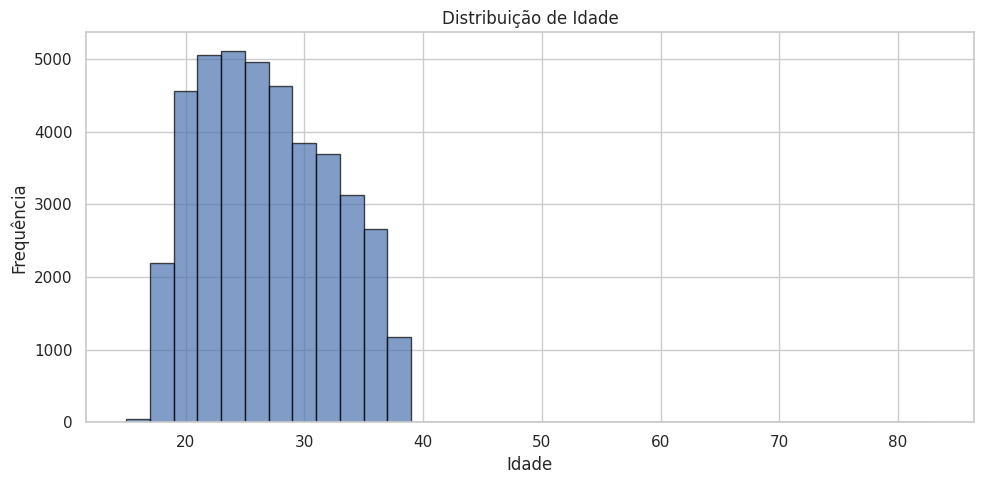

In [28]:
# 9.1 Distribuição de Idade
fig, ax = plt.subplots(figsize=(10, 5))
ax.hist(df['Age'], bins=range(15, 85, 2), edgecolor='black', alpha=0.7)
ax.set_xlabel('Idade')
ax.set_ylabel('Frequência')
ax.set_title('Distribuição de Idade')
plt.tight_layout()
plt.savefig('../results/dist_age.png', dpi=150)
plt.show()

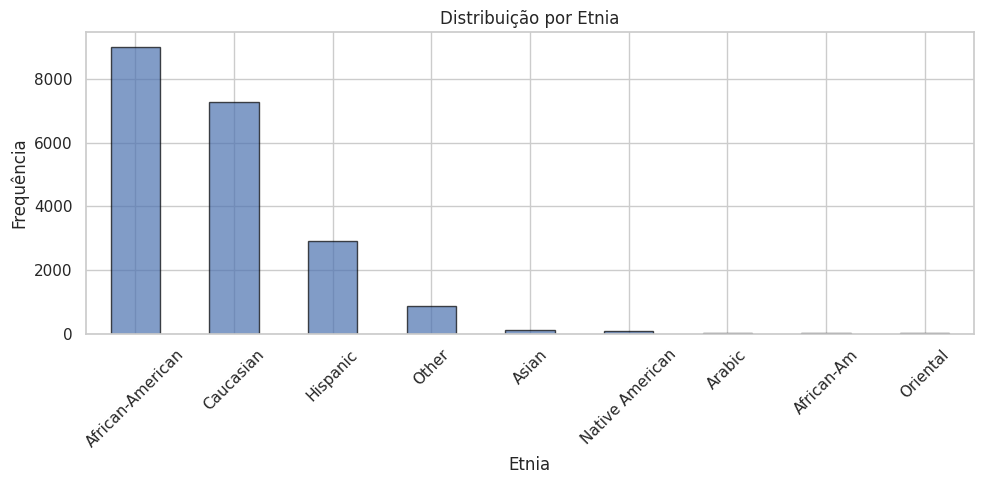

In [29]:
# 9.2 Distribuição por Etnia
fig, ax = plt.subplots(figsize=(10, 5))
ethnic_counts = recid['Ethnic_Code_Text'].value_counts()
ethnic_counts.plot(kind='bar', ax=ax, edgecolor='black', alpha=0.7)
ax.set_xlabel('Etnia')
ax.set_ylabel('Frequência')
ax.set_title('Distribuição por Etnia')
ax.tick_params(axis='x', rotation=45)
plt.tight_layout()
plt.savefig('../results/dist_ethnicity.png', dpi=150)
plt.show()

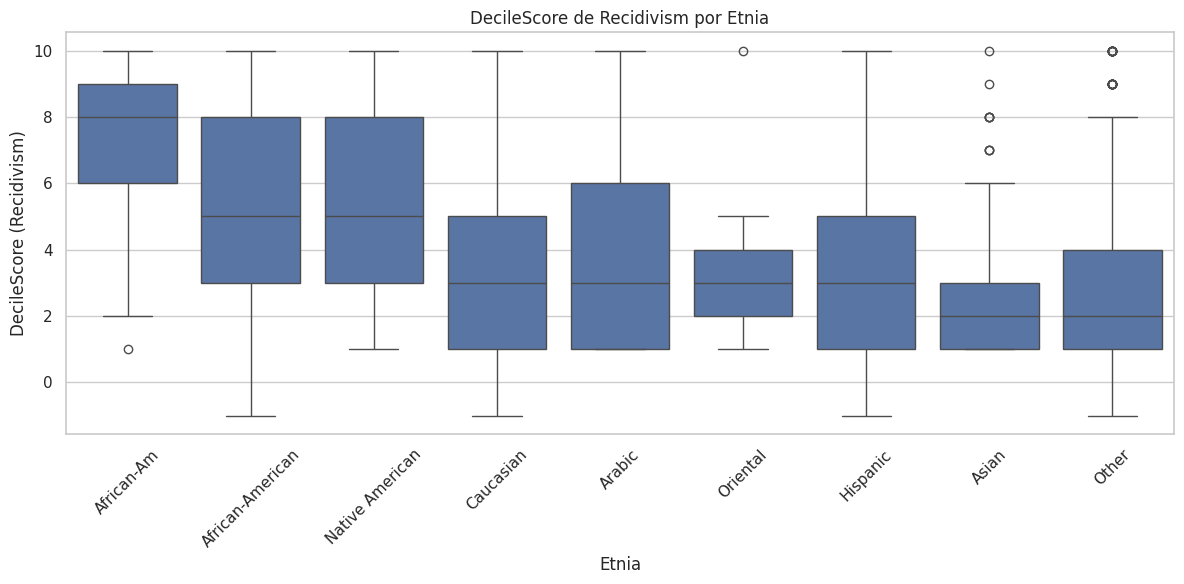

In [ ]:
# 9.3 DecileScore de Recidivism por Etnia
fig, ax = plt.subplots(figsize=(12, 6))
order = recid.groupby('Ethnic_Code_Text')['DecileScore'].median().sort_values(ascending=False).index
sns.boxplot(data=recid, x='Ethnic_Code_Text', y='DecileScore', order=order, ax=ax)
ax.set_xlabel('Etnia')
ax.set_ylabel('DecileScore (Recidivism)')
ax.set_title('DecileScore de Recidivism por Etnia')
ax.tick_params(axis='x', rotation=45)
plt.tight_layout()
plt.savefig('../results/boxplot_decile_by_ethnicity.png', dpi=150)
plt.show()

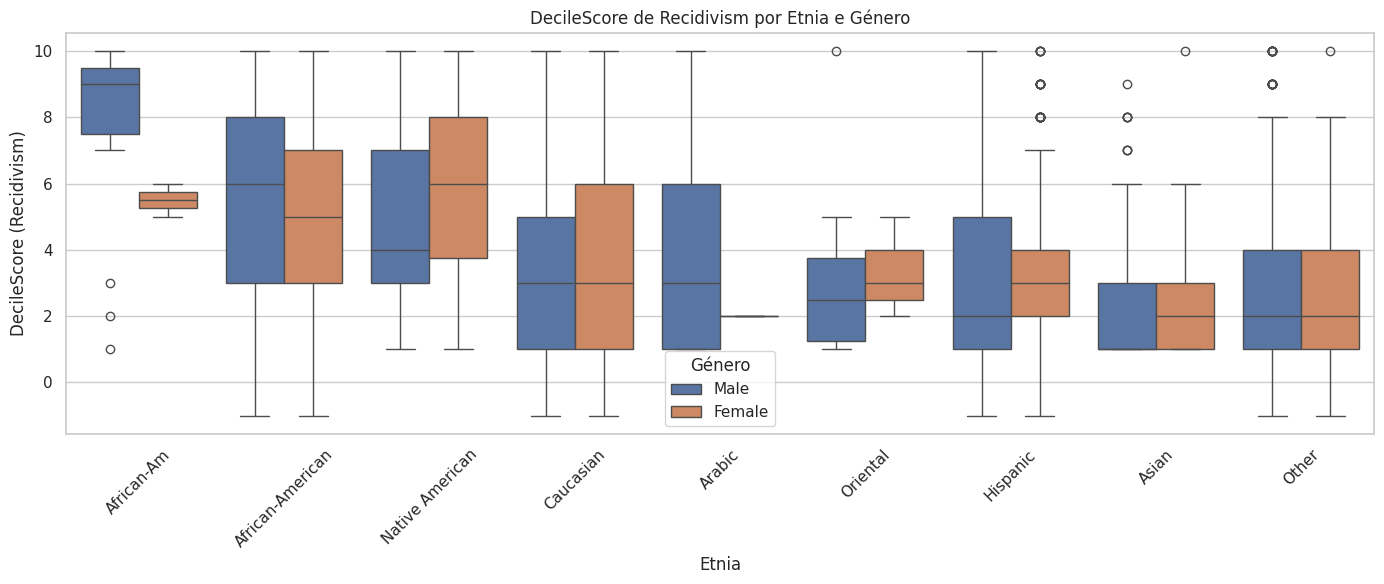

In [ ]:
# 9.4 DecileScore de Recidivism por Etnia x Género
fig, ax = plt.subplots(figsize=(14, 6))
sns.boxplot(data=recid, x='Ethnic_Code_Text', y='DecileScore', hue='Sex_Code_Text', order=order, ax=ax)
ax.set_xlabel('Etnia')
ax.set_ylabel('DecileScore (Recidivism)')
ax.set_title('DecileScore de Recidivism por Etnia e Género')
ax.tick_params(axis='x', rotation=45)
ax.legend(title='Género')
plt.tight_layout()
plt.savefig('../results/boxplot_decile_by_ethnicity_gender.png', dpi=150)
plt.show()

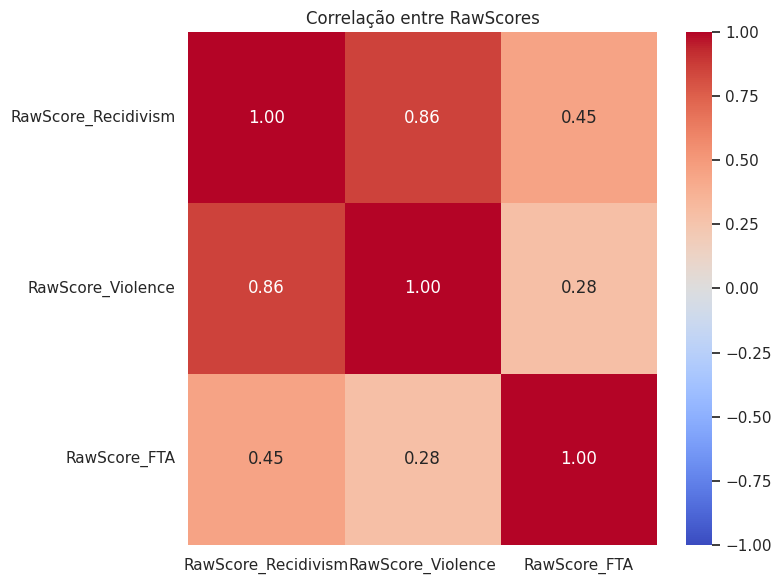

In [ ]:
# 9.5 Correlação entre os 3 tipos de score
recid_pivot = recid[['Person_ID', 'RawScore']].copy()
violence = df[df['DisplayText'] == 'Risk of Violence'][['Person_ID', 'RawScore']].rename(columns={'RawScore': 'RawScore_Violence'})
fta = df[df['DisplayText'] == 'Risk of Failure to Appear'][['Person_ID', 'RawScore']].rename(columns={'RawScore': 'RawScore_FTA'})
recid_pivot = recid_pivot.rename(columns={'RawScore': 'RawScore_Recidivism'})

scores = recid_pivot.merge(violence, on='Person_ID').merge(fta, on='Person_ID')

fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(scores[['RawScore_Recidivism', 'RawScore_Violence', 'RawScore_FTA']].corr(),
            annot=True, cmap='coolwarm', vmin=-1, vmax=1, ax=ax, fmt='.2f')
ax.set_title('Correlação entre RawScores')
plt.tight_layout()
plt.savefig('../results/heatmap_score_correlation.png', dpi=150)
plt.show()

## 10. Resumo das Decisões

### Colunas a REMOVER
| Coluna | Razão |
|---|---|
| `Person_ID`, `AssessmentID`, `Case_ID` | Identifying (IDs internos) |
| `FirstName`, `LastName`, `MiddleName` | Identifying (nomes) |
| `DateOfBirth` | Identifying (convertido para `Age`) |
| `Screening_Date` | Convertido para `Screening_Year` |
| `ScaleSet_ID`, `Scale_ID` | IDs internos do sistema |
| `ScaleSet` | 96% um valor, pouca variação |
| `AssessmentReason` | Só 1 valor ("Intake") |
| `IsCompleted`, `IsDeleted` | Só 1 valor cada |
| `AssessmentType` | Metadata |
| `DisplayText` | Usado para pivotar, removido depois |
| `ScoreText` | Redundante (derivável de DecileScore) |
| `RecSupervisionLevel` | Redundante com `RecSupervisionLevelText` |

### Colunas a MANTER (após pivotar)
| Coluna | Classificação | Valores únicos |
|---|---|---|
| `Age` (derivado) | Quasi-identifying | contínuo |
| `Sex_Code_Text` | Quasi-identifying | 2 |
| `Ethnic_Code_Text` | Quasi-identifying | 9 |
| `MaritalStatus` | Quasi-identifying | 7 |
| `Language` | Quasi-identifying | 2 |
| `LegalStatus` | Quasi-identifying | 7 |
| `CustodyStatus` | Quasi-identifying | 6 |
| `Screening_Year` (derivado) | Quasi-identifying | ~3 |
| `Agency_Text` | Insensitive | 4 |
| `RecSupervisionLevelText` | Sensitive | 4 |
| `RawScore_Recidivism` | Sensitive | contínuo |
| `RawScore_Violence` | Sensitive | contínuo |
| `RawScore_FTA` | Sensitive | contínuo |
| `DecileScore_Recidivism` | Sensitive | 1-10 |
| `DecileScore_Violence` | Sensitive | 1-10 |
| `DecileScore_FTA` | Sensitive | 1-10 |

### Próximo passo
Sanitizar e pivotar o dataset no notebook `02_sanitize.ipynb`.